# Monitor training — plot `training_info.csv`

Reusable plots for the metrics logged during training
(`ckp/monitor_training/.../*_training_info.csv`).

The core is **`plot_training_info(df, columns, ...)`** — pass the list of
columns you want drawn against `epoch`. Use `normalize=True` to compare
metrics that live on different scales (e.g. loss vs. accuracy) on a single
axis (min–max scaled to `[0, 1]`).

Numeric columns available: `lr, time, train_loss, train_acc, trainS_loss,
trainS_acc, trainS_pgd, val_loss, val_acc, val_pgd, path_drift_step,
path_drift_endpoint, path_cos`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the training-info CSV (relative to this notebook). Point this at any
# other run's *_training_info.csv to reuse the plots below.
CSV_PATH = (
    "../../ckp/monitor_training/cifar10/resnet18/adv_pgd/"
    "resnet18_cifar10_adv_pgd_training_info.csv"
)

df = pd.read_csv(CSV_PATH)
df

,arch,dataset,training_type,epoch,lr,time,train_loss,train_acc,trainS_loss,trainS_acc,trainS_pgd,val_loss,val_acc,val_pgd,path_drift_step,path_drift_endpoint,path_cos
0,resnet18,cifar10,adv_pgd,5,0.009938,13.180662,1.941848,0.27952,1.596852,0.4462,0.2758,1.619967,0.4369,0.2653,0.501635,0.634566,0.782453
1,resnet18,cifar10,adv_pgd,10,0.009755,13.403208,1.839540,0.31408,1.455476,0.4929,0.3033,1.518148,0.4668,0.2747,0.571096,0.736210,0.717922
2,resnet18,cifar10,adv_pgd,15,0.009455,13.506423,1.740818,0.34472,1.312319,0.5588,0.3405,1.445305,0.4883,0.2749,0.606106,0.763927,0.681517
3,resnet18,cifar10,adv_pgd,20,0.009045,13.526107,1.625652,0.37942,1.150824,0.6146,0.3597,1.396653,0.5036,0.2590,0.703841,0.884273,0.568558
4,resnet18,cifar10,adv_pgd,25,0.008536,13.564536,1.491800,0.41808,1.012842,0.6903,0.4036,1.369658,0.5159,0.2320,0.762524,0.967116,0.489452
5,resnet18,cifar10,adv_pgd,30,0.007939,13.601439,1.343886,0.45648,0.842523,0.7422,0.4285,1.362483,0.5263,0.2203,0.765584,0.969737,0.486829
6,resnet18,cifar10,adv_pgd,35,0.007270,13.639337,1.193354,0.49764,0.659494,0.8013,0.4264,1.453562,0.5262,0.1998,0.785550,0.989353,0.460501
7,resnet18,cifar10,adv_pgd,40,0.006545,13.650244,1.035774,0.53778,0.569807,0.8335,0.5067,1.475365,0.5292,0.1843,0.757013,0.938276,0.492932
8,resnet18,cifar10,adv_pgd,45,0.005782,13.510202,0.898247,0.58558,0.434408,0.8769,0.5373,1.575998,0.5328,0.1701,0.773151,0.982133,0.460791
9,resnet18,cifar10,adv_pgd,50,0.005000,13.497667,0.774679,0.64986,0.341809,0.9046,0.6188,1.603145,0.5416,0.1679,0.854870,1.074373,0.344944


In [2]:
# Colorblind-safe categorical palette (Okabe–Ito), assigned in fixed order.
_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
]


def plot_training_info(
    df,
    columns,
    x="epoch",
    ax=None,
    title=None,
    normalize=False,
    marker="o",
    figsize=(9, 5),
):
    """Plot selected metric columns against `x` (default 'epoch').

    Parameters
    ----------
    df : pandas.DataFrame
        Training-info table (as loaded from *_training_info.csv).
    columns : list[str]
        Column names to plot on the y-axis, one line each.
    x : str
        Column used for the x-axis (default 'epoch').
    ax : matplotlib.axes.Axes, optional
        Axis to draw on; a new figure/axis is created if omitted.
    title : str, optional
        Plot title. A sensible default is built from the columns.
    normalize : bool
        If True, min–max scale each column to [0, 1] so metrics on
        different scales (e.g. loss vs. accuracy) share one axis.
    marker : str
        Marker style for the line points.
    figsize : tuple
        Figure size when a new axis is created.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if isinstance(columns, str):
        columns = [columns]

    missing = [c for c in [x, *columns] if c not in df.columns]
    if missing:
        raise KeyError(
            f"Column(s) not found in dataframe: {missing}. "
            f"Available: {list(df.columns)}"
        )

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    xs = df[x]
    for i, col in enumerate(columns):
        ys = df[col]
        if normalize:
            lo, hi = ys.min(), ys.max()
            ys = (ys - lo) / (hi - lo) if hi > lo else ys * 0.0
        ax.plot(
            xs,
            ys,
            marker=marker,
            markersize=5,
            linewidth=2,
            color=_PALETTE[i % len(_PALETTE)],
            label=col,
        )

    ax.set_xlabel(x)
    ax.set_ylabel("normalized value" if normalize else "value")
    if title is None:
        title = "Training info: " + ", ".join(columns)
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.4)
    if len(columns) >= 2:
        ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

## Examples

Pass whichever columns you care about.

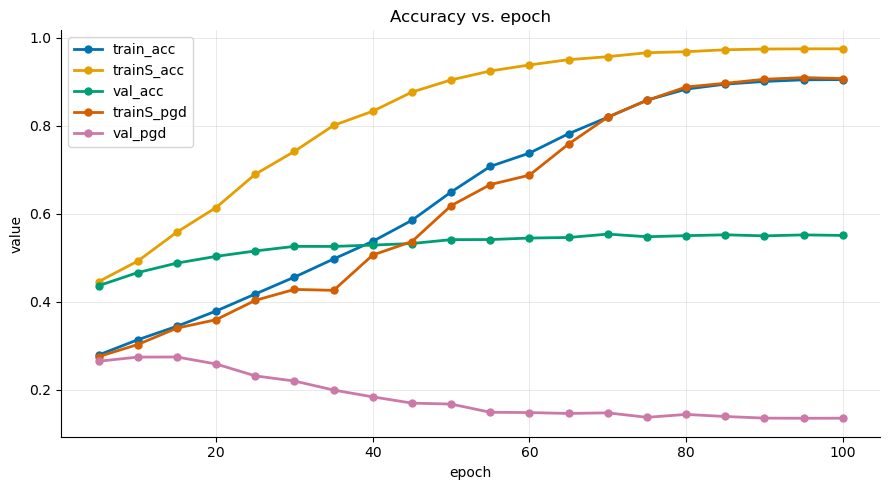

In [3]:
# Accuracies (clean, strong-aug, val, and PGD-robust) — all on the same [0,1] scale.
plot_training_info(
    df,
    ["train_acc", "trainS_acc", "val_acc", "trainS_pgd", "val_pgd"],
    title="Accuracy vs. epoch",
)
plt.tight_layout()
plt.show()

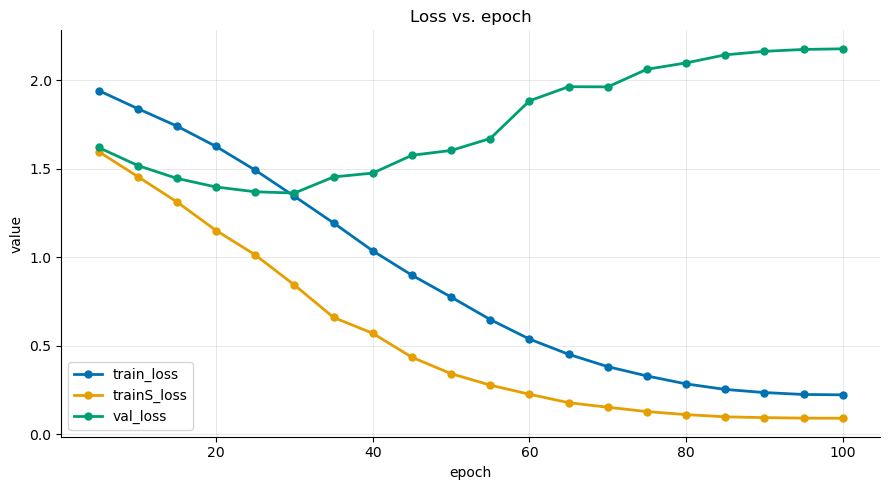

In [4]:
# Losses.
plot_training_info(
    df,
    ["train_loss", "trainS_loss", "val_loss"],
    title="Loss vs. epoch",
)
plt.tight_layout()
plt.show()

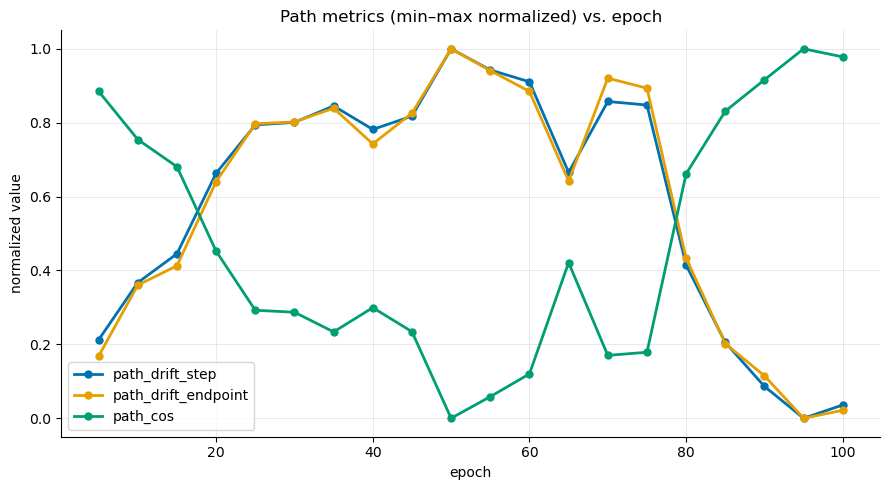

In [5]:
# Path-drift metrics live on different scales — use normalize=True to compare shapes.
plot_training_info(
    df,
    ["path_drift_step", "path_drift_endpoint", "path_cos"],
    normalize=True,
    title="Path metrics (min–max normalized) vs. epoch",
)
plt.tight_layout()
plt.show()